<a href="https://www.kaggle.com/code/mashrur135/nb-01?scriptVersionId=339710545" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# CSE 438 - Assignment Part B

## Notebook 1: Data Preparation (Task A)

### Dataset
Semantic Drone Dataset (aerial nadir imagery)

### Objective
Reuse the exact train/validation/test split from Part A (no re-shuffling) and
build the three role-specific data pipelines required for Part B:

- **Train split** -> unlabelled SSL pretraining pool (images only, masks ignored)
- **Validation split** -> labelled fine-tuning set (image + mask, augmented, synced)
- **Test split** -> downstream monitoring + final evaluation (image + mask, deterministic)

This notebook also verifies there is **no leakage** across splits, and produces
a sanity-check visualization using the *exact same transforms* used in training,
before any GPU time is spent on SSL pretraining.

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import cv2

import torch
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")


/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


## Config cell
Report the exact image counts and augmentation choices from this cell in
Section 6.3 of the report.

In [2]:
# =========================
# Configuration
# =========================

CONFIG = {
    "train_csv": "/kaggle/input/datasets/mashrur135/result/split/train_split.csv",
    "valid_csv": "/kaggle/input/datasets/mashrur135/result/split/valid_split.csv",
    "test_csv":  "/kaggle/input/datasets/mashrur135/result/split/test_split.csv",

    "image_size": 512,
    "batch_size": 8,
    "num_workers": 2,
    "seed": 42,
}


In [3]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CONFIG["seed"])


## Stage 1: Load Part-A splits (unmodified)

We load the exact same CSVs produced in Part A. No re-splitting, no re-shuffling.

In [4]:
train_df = pd.read_csv(CONFIG["train_csv"])
valid_df = pd.read_csv(CONFIG["valid_csv"])
test_df  = pd.read_csv(CONFIG["test_csv"])

# Confirm required columns exist before going any further
required_cols = {"image_path", "mask_path", "pair_key"}
for name, df in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    missing = required_cols - set(df.columns)
    assert not missing, f"{name}.csv is missing columns: {missing}"


In [5]:
print("=" * 40)
print(f"Train      : {len(train_df)}")
print(f"Validation : {len(valid_df)}")
print(f"Test       : {len(test_df)}")
print("=" * 40)

train_df.head()


Train      : 280
Validation : 60
Test       : 60


,image_path,mask_path,image_name,pair_key
0,/kaggle/input/datasets/bulentsiyah/semantic-dr...,/kaggle/input/datasets/bulentsiyah/semantic-dr...,226.jpg,226
1,/kaggle/input/datasets/bulentsiyah/semantic-dr...,/kaggle/input/datasets/bulentsiyah/semantic-dr...,161.jpg,161
2,/kaggle/input/datasets/bulentsiyah/semantic-dr...,/kaggle/input/datasets/bulentsiyah/semantic-dr...,023.jpg,23
3,/kaggle/input/datasets/bulentsiyah/semantic-dr...,/kaggle/input/datasets/bulentsiyah/semantic-dr...,521.jpg,521
4,/kaggle/input/datasets/bulentsiyah/semantic-dr...,/kaggle/input/datasets/bulentsiyah/semantic-dr...,041.jpg,41


## Stage 1b: Leakage check (required before trusting the split)

The whole Part-A vs Part-B comparison is only fair if train/validation/test
never share an image. `pair_key` uniquely identifies each source image, so we
check pairwise disjointness across all three splits. This is exactly the kind
of check viva will ask you to justify -- keep this cell's output visible.

In [6]:
train_keys = set(train_df["pair_key"])
valid_keys = set(valid_df["pair_key"])
test_keys  = set(test_df["pair_key"])

assert train_keys.isdisjoint(valid_keys), "Leakage detected: train/valid overlap!"
assert train_keys.isdisjoint(test_keys),  "Leakage detected: train/test overlap!"
assert valid_keys.isdisjoint(test_keys),  "Leakage detected: valid/test overlap!"

print("No leakage across splits ✅")
print(f"Total unique pair_keys: {len(train_keys) + len(valid_keys) + len(test_keys)}")


No leakage across splits ✅
Total unique pair_keys: 400


## Stage 2: Role reassignment (conceptual)

| Split | Part-B role | Masks used? | Augmentation |
|---|---|---|---|
| train.csv | Unlabelled SSL pretraining corpus | No (ignored) | Strong, two independent views |
| valid.csv | Labelled fine-tuning set | Yes | Light, synced image+mask |
| test.csv  | Monitoring + final eval | Yes | None (deterministic) |

**Fix vs. the original draft:** validation must use its own *augmented* transform
(the assignment requires reusing an augmentation pipeline for fine-tuning, not a
bare resize). It should not be identical to the test transform -- test stays
fully deterministic since it is used for both checkpoint selection and final
reported metrics.

In [7]:
# =========================
# Transforms
# =========================

# (a) SSL pretraining -- train split, images only, two independent augmented views.
# Vertical flip is included because this is nadir aerial imagery: there is no
# fixed "up", unlike street-level photos.
ssl_transform = A.Compose([
    A.RandomResizedCrop(size=(CONFIG["image_size"], CONFIG["image_size"]),
                         scale=(0.5, 1.0), ratio=(0.9, 1.1)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(),
    ToTensorV2(),
])

# (b) Labelled fine-tuning -- validation split, image+mask, synced light augmentation.
# albumentations applies the SAME random parameters to image and mask automatically
# when both are passed to the same A.Compose call.
finetune_transform = A.Compose([
    A.Resize(CONFIG["image_size"], CONFIG["image_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2(),
])

# (c) Deterministic eval -- test split, resize/normalize only, no randomness.
eval_transform = A.Compose([
    A.Resize(CONFIG["image_size"], CONFIG["image_size"]),
    A.Normalize(),
    ToTensorV2(),
])


## Stage 3: Dataset class

Mask loading uses `cv2.IMREAD_GRAYSCALE` consistently everywhere in this
notebook (dataset class AND the sanity-check cells below) -- the original
draft read masks two different ways in different cells, which can silently
give different pixel values if the mask PNGs are stored as RGB. Before
trusting this, run the check in the cell right after the class definition.

In [8]:
class DroneDataset(Dataset):
    def __init__(self, dataframe, transform=None, use_mask=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.use_mask = use_mask

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.iloc[idx]["image_path"]
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.use_mask:
            mask_path = self.df.iloc[idx]["mask_path"]
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if self.transform:
                augmented = self.transform(image=image, mask=mask)
                image = augmented["image"]
                mask = augmented["mask"]

            return image, mask
        else:
            if self.transform:
                image = self.transform(image=image)["image"]
            return image


In [9]:
# Quick check: confirm IMREAD_GRAYSCALE gives clean class-index values,
# not smoothed/blended values from an RGB-encoded mask.
_sample_mask_path = train_df.iloc[0]["mask_path"] if "mask_path" in train_df.columns else valid_df.iloc[0]["mask_path"]
_mask_gray = cv2.imread(_sample_mask_path, cv2.IMREAD_GRAYSCALE)
print(f"Mask shape: {_mask_gray.shape}, unique values: {np.unique(_mask_gray)[:20]}")
print("If these look like clean small integers (0,1,2,3...), grayscale loading is correct.")
print("If they look like arbitrary large numbers, the mask may be RGB-encoded -- inspect further.")


Mask shape: (4000, 6000), unique values: [ 0  1  2  3  4  8  9 10 11 13 14 15 22]
If these look like clean small integers (0,1,2,3...), grayscale loading is correct.
If they look like arbitrary large numbers, the mask may be RGB-encoded -- inspect further.


## Stage 4: Instantiate datasets and dataloaders

In [10]:
# ==========================
# Create Dataset Objects
# ==========================

ssl_dataset = DroneDataset(
    train_df,
    transform=ssl_transform,
    use_mask=False,
)

valid_dataset = DroneDataset(
    valid_df,
    transform=finetune_transform,   # augmented, unlike the original draft
    use_mask=True,
)

test_dataset = DroneDataset(
    test_df,
    transform=eval_transform,       # deterministic
    use_mask=True,
)


In [11]:
ssl_train_loader = DataLoader(
    ssl_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    drop_last=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
)


In [12]:
print(f"SSL Train Batches : {len(ssl_train_loader)}")
print(f"Validation Batches: {len(valid_loader)}")
print(f"Test Batches      : {len(test_loader)}")


SSL Train Batches : 35
Validation Batches: 8
Test Batches      : 8


## Stage 5: Sanity-check grid

Both panels below reuse the **exact transform objects defined above**
(`ssl_transform`, `finetune_transform`) rather than a separate lookalike
transform -- so this check actually proves the training pipeline is wired
correctly, not just a similar-looking one.

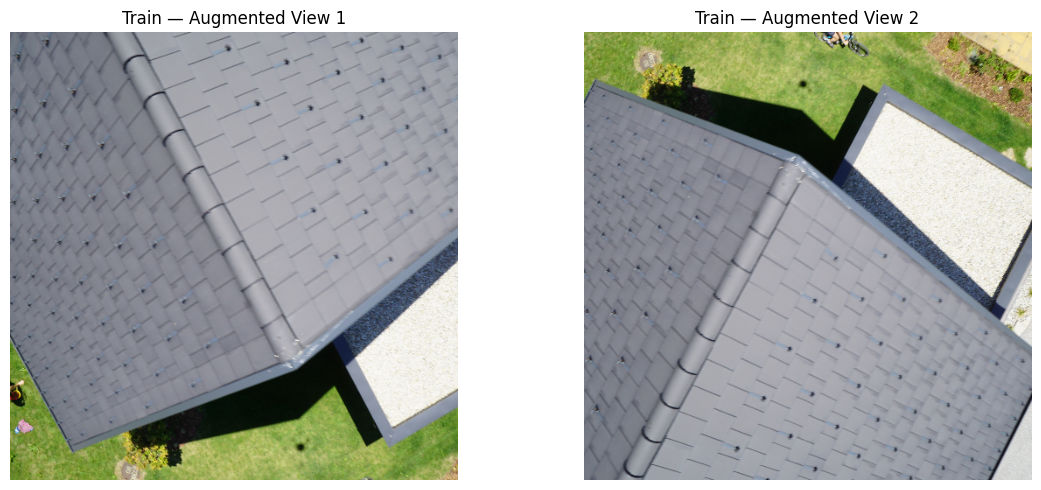

In [13]:
# (a) Two augmented views of the same train image, using the REAL ssl_transform
idx = random.randint(0, len(train_df) - 1)
image_path = train_df.iloc[idx]["image_path"]

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

view1 = ssl_transform(image=image)["image"]
view2 = ssl_transform(image=image)["image"]

def denorm(img_tensor):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    img = img_tensor.numpy() * std + mean
    return np.clip(img.transpose(1, 2, 0), 0, 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(denorm(view1))
plt.title("Train — Augmented View 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(denorm(view2))
plt.title("Train — Augmented View 2")
plt.axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/sanity_ssl_views.png", dpi=150, bbox_inches="tight")
plt.show()


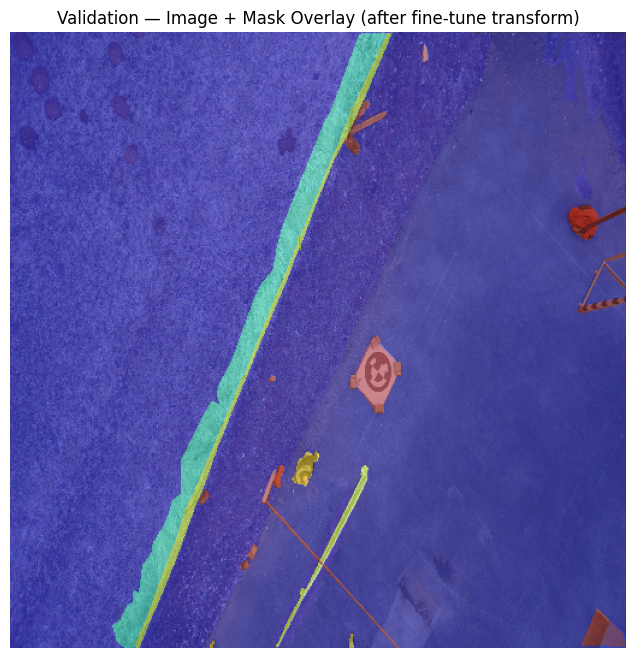

In [14]:
# (b) Validation image + mask overlay, using the REAL finetune_transform
idx = random.randint(0, len(valid_df) - 1)
image_path = valid_df.iloc[idx]["image_path"]
mask_path = valid_df.iloc[idx]["mask_path"]

image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)   # consistent with DroneDataset

augmented = finetune_transform(image=image, mask=mask)
vis_image = denorm(augmented["image"])
vis_mask = augmented["mask"]

plt.figure(figsize=(8, 8))
plt.imshow(vis_image)
plt.imshow(vis_mask, alpha=0.45, cmap="jet")
plt.title("Validation — Image + Mask Overlay (after fine-tune transform)")
plt.axis("off")
plt.savefig("/kaggle/working/sanity_val_overlay.png", dpi=150, bbox_inches="tight")
plt.show()


## Stage 6: Save split artifacts for the SSL method notebooks

Saved under `/kaggle/working` so that setting this notebook's output to
Public and adding it as a Kaggle dataset input lets every SimCLR/BYOL/MAE/DINOv2
notebook load the identical split -- no re-splitting, ever.

In [15]:
os.makedirs("/kaggle/working/artifacts/splits", exist_ok=True)

train_df.to_csv("/kaggle/working/artifacts/splits/train_split.csv", index=False)
valid_df.to_csv("/kaggle/working/artifacts/splits/valid_split.csv", index=False)
test_df.to_csv("/kaggle/working/artifacts/splits/test_split.csv", index=False)

print("Split files saved to /kaggle/working/artifacts/splits/")
print("Set this notebook's output to Public, then add it as a dataset input")
print("in the SimCLR / BYOL / MAE / DINOv2 notebooks.")


Split files saved to /kaggle/working/artifacts/splits/
Set this notebook's output to Public, then add it as a dataset input
in the SimCLR / BYOL / MAE / DINOv2 notebooks.
